In [155]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [156]:
df0 = pd.read_csv(r'C:\Users\meet.gajera\OneDrive\Desktop\hcdr__\Data\row\bureau.csv')

In [157]:
df = df0[['SK_ID_CURR',
           'CREDIT_ACTIVE',
           'DAYS_CREDIT',
           'AMT_CREDIT_SUM',
           'AMT_CREDIT_SUM_DEBT',
           'AMT_CREDIT_SUM_LIMIT',]].copy()

In [158]:
df.head()

,SK_ID_CURR,CREDIT_ACTIVE,DAYS_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT
0,215354,Closed,-497,91323.0,0.0,NaN
1,215354,Active,-208,225000.0,171342.0,NaN
2,215354,Active,-203,464323.5,NaN,NaN
3,215354,Active,-203,90000.0,NaN,NaN
4,215354,Active,-629,2700000.0,NaN,NaN


In [159]:
df.shape

(1716428, 6)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 6 columns):
 #   Column                Dtype  
---  ------                -----  
 0   SK_ID_CURR            int64  
 1   CREDIT_ACTIVE         object 
 2   DAYS_CREDIT           int64  
 3   AMT_CREDIT_SUM        float64
 4   AMT_CREDIT_SUM_DEBT   float64
 5   AMT_CREDIT_SUM_LIMIT  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 78.6+ MB


In [161]:
df.describe()

,SK_ID_CURR,DAYS_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT
count,1.716428e+06,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06
mean,2.782149e+05,-1.142108e+03,3.549946e+05,1.370851e+05,6.229515e+03
std,1.029386e+05,7.951649e+02,1.149811e+06,6.774011e+05,4.503203e+04
min,1.000010e+05,-2.922000e+03,0.000000e+00,-4.705600e+06,-5.864061e+05
25%,1.888668e+05,-1.666000e+03,5.130000e+04,0.000000e+00,0.000000e+00
50%,2.780550e+05,-9.870000e+02,1.255185e+05,0.000000e+00,0.000000e+00
75%,3.674260e+05,-4.740000e+02,3.150000e+05,4.015350e+04,0.000000e+00
max,4.562550e+05,0.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06


In [162]:
df.isnull().sum()

SK_ID_CURR                   0
CREDIT_ACTIVE                0
DAYS_CREDIT                  0
AMT_CREDIT_SUM              13
AMT_CREDIT_SUM_DEBT     257669
AMT_CREDIT_SUM_LIMIT    591780
dtype: int64

In [163]:
df.duplicated().sum()

6703

In [164]:
df.drop_duplicates(inplace=True)

In [165]:
df.isnull().sum()

SK_ID_CURR                   0
CREDIT_ACTIVE                0
DAYS_CREDIT                  0
AMT_CREDIT_SUM              13
AMT_CREDIT_SUM_DEBT     257198
AMT_CREDIT_SUM_LIMIT    590414
dtype: int64

### AMT_CREDIT_SUM

In [166]:
# checking impossible values

(df['AMT_CREDIT_SUM']<0).sum()

0

In [167]:
df['AMT_CREDIT_SUM'].describe()

count    1.709712e+06
mean     3.547972e+05
std      1.141066e+06
min      0.000000e+00
25%      5.151150e+04
50%      1.255500e+05
75%      3.150000e+05
max      5.850000e+08
Name: AMT_CREDIT_SUM, dtype: float64

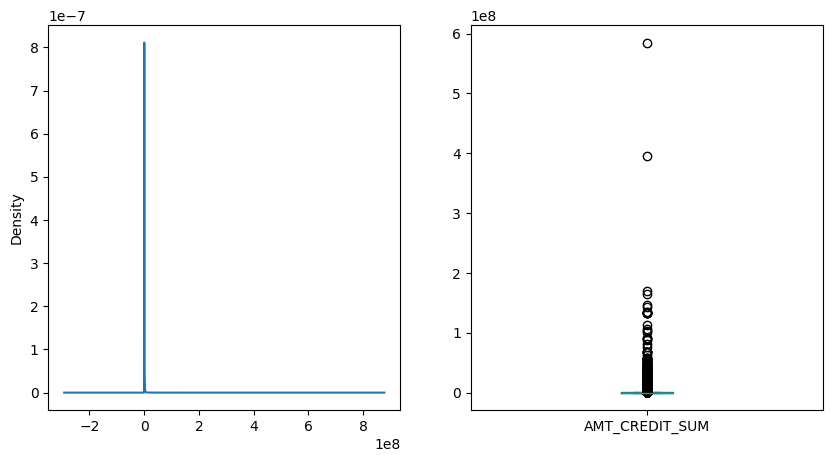

Skewness:  126.06501816602497


In [168]:
plt.figure(figsize=(10,5))
plt.subplot(121)
df['AMT_CREDIT_SUM'].plot(kind='kde')
plt.subplot(122)
df['AMT_CREDIT_SUM'].plot(kind='box')
plt.show()

print('Skewness: ',df['AMT_CREDIT_SUM'].skew())

In [169]:
# missing values are very less so,
df = df.dropna(subset=['AMT_CREDIT_SUM'])

In [170]:
df['AMT_CREDIT_SUM_trans'] = np.log1p(df['AMT_CREDIT_SUM'])

df.insert(
    df.columns.get_loc('AMT_CREDIT_SUM')+1,
    'AMT_CREDIT_SUM_trans',
    df.pop('AMT_CREDIT_SUM_trans')
)

In [171]:
print('before: ',df['AMT_CREDIT_SUM'].skew())
print('after: ',df['AMT_CREDIT_SUM_trans'].skew())

before:  126.06501816602501
after:  -3.0571519210174443


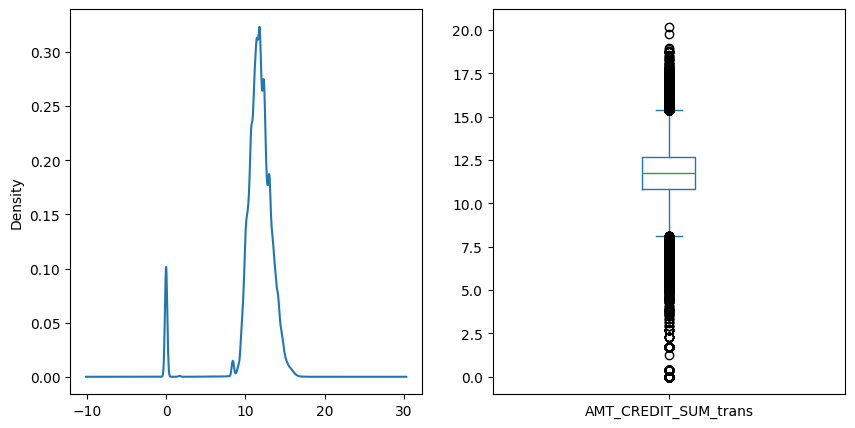

In [172]:
plt.figure(figsize=(10,5))
plt.subplot(121)
df['AMT_CREDIT_SUM_trans'].plot(kind='kde')
plt.subplot(122)
df['AMT_CREDIT_SUM_trans'].plot(kind='box')
plt.show()

### AMT_CREDIT_SUM_DEBT

In [173]:
df['AMT_CREDIT_SUM_DEBT'].describe()

count    1.452514e+06
mean     1.375842e+05
std      6.784591e+05
min     -4.705600e+06
25%      0.000000e+00
50%      0.000000e+00
75%      4.099500e+04
max      1.701000e+08
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

In [174]:
df['AMT_CREDIT_SUM_DEBT'].isnull().sum()

257198

In [175]:
(df['AMT_CREDIT_SUM_DEBT'] < 0).sum()

8319

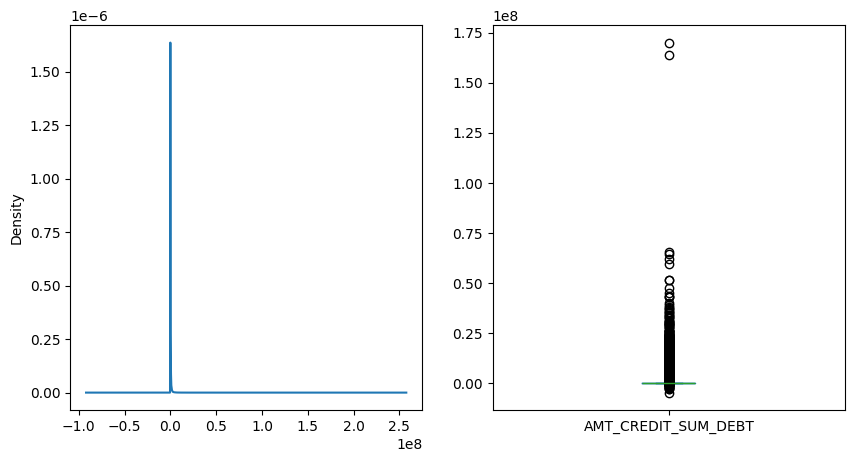

Skewness:  36.379527151420476


In [176]:
plt.figure(figsize=(10,5))
plt.subplot(121)
df['AMT_CREDIT_SUM_DEBT'].plot(kind='kde')
plt.subplot(122)
df['AMT_CREDIT_SUM_DEBT'].plot(kind='box')
plt.show()

print('Skewness: ',df['AMT_CREDIT_SUM_DEBT'].skew())

In [177]:
pd.crosstab(
    df['CREDIT_ACTIVE'],
    df['AMT_CREDIT_SUM_DEBT'].isna(),
    normalize='index'
) * 100

AMT_CREDIT_SUM_DEBT,False,True
CREDIT_ACTIVE,,
Active,88.299658,11.700342
Bad debt,71.428571,28.571429
Closed,83.242774,16.757226
Sold,45.457355,54.542645


In [178]:
df['AMT_CREDIT_SUM_DEBT_MISSING'] = df['AMT_CREDIT_SUM_DEBT'].isnull().astype(int)

df.insert(
    df.columns.get_loc('AMT_CREDIT_SUM_DEBT')+1,
    'AMT_CREDIT_SUM_DEBT_MISSING',
    df.pop('AMT_CREDIT_SUM_DEBT_MISSING')
)

df['AMT_CREDIT_SUM_DEBT'] = df['AMT_CREDIT_SUM_DEBT'].fillna(df['AMT_CREDIT_SUM_DEBT'].median())

- `AMT_CREDIT_SUM_DEBT had approximately 15% missing values. Missingness was analyzed against CREDIT_ACTIVE and was not concentrated in a single credit status, indicating that missing values could not be safely interpreted as zero outstanding debt. Therefore, missing values were imputed using the median, and a binary missing-value indicator feature was added to preserve missingness information.`

In [179]:
# here we use Yeo-Johnson, because there is large number of -ve values.

from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')

df['AMT_CREDIT_SUM_DEBT_trans'] = pt.fit_transform(df[['AMT_CREDIT_SUM_DEBT']])

df.insert(
    df.columns.get_loc('AMT_CREDIT_SUM_DEBT_MISSING')+1,
    'AMT_CREDIT_SUM_DEBT_trans',
    df.pop('AMT_CREDIT_SUM_DEBT_trans')
)

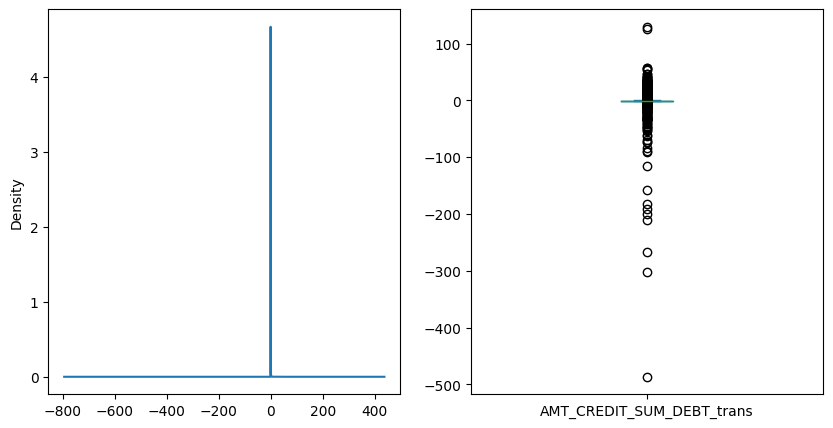

Skewness:  -110.8302582174586


In [180]:
plt.figure(figsize=(10,5))
plt.subplot(121)
df['AMT_CREDIT_SUM_DEBT_trans'].plot(kind='kde')
plt.subplot(122)
df['AMT_CREDIT_SUM_DEBT_trans'].plot(kind='box')
plt.show()

print('Skewness: ',df['AMT_CREDIT_SUM_DEBT_trans'].skew())

- it's much worse than the original skewness (36.38).

In [181]:
df.drop(columns=['AMT_CREDIT_SUM_DEBT_trans'], inplace=True)

### AMT_CREDIT_SUM_LIMIT

In [182]:
df['AMT_CREDIT_SUM_LIMIT'].describe()

count    1.119311e+06
mean     6.239246e+03
std      4.507936e+04
min     -5.864061e+05
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.705600e+06
Name: AMT_CREDIT_SUM_LIMIT, dtype: float64

- at least 75% of the observed values are already zero.

In [183]:
df['AMT_CREDIT_SUM_LIMIT'].isnull().sum()

590401

- 34.40% missing values

In [184]:
(df['AMT_CREDIT_SUM_LIMIT']<0).sum()

351

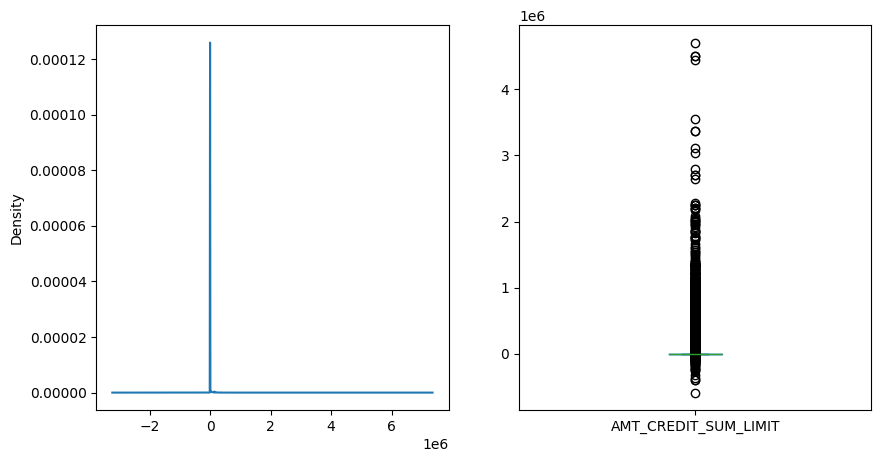

Skewness:  18.029291515388834


In [185]:
plt.figure(figsize=(10,5))
plt.subplot(121)
df['AMT_CREDIT_SUM_LIMIT'].plot(kind='kde')
plt.subplot(122)
df['AMT_CREDIT_SUM_LIMIT'].plot(kind='box')
plt.show()

print('Skewness: ',df['AMT_CREDIT_SUM_LIMIT'].skew())

In [186]:
pd.crosstab(
    df['CREDIT_ACTIVE'],
    df['AMT_CREDIT_SUM_LIMIT'].isna(),
    normalize='index'
) * 100

AMT_CREDIT_SUM_LIMIT,False,True
CREDIT_ACTIVE,,
Active,72.428495,27.571505
Bad debt,57.142857,42.857143
Closed,61.649387,38.350613
Sold,24.675525,75.324475


In [187]:
# missing indicator
df['AMT_CREDIT_SUM_LIMIT_MISSING'] = (df['AMT_CREDIT_SUM_LIMIT'].isna().astype(int))

df.insert(
    df.columns.get_loc('AMT_CREDIT_SUM_LIMIT')+1,
    'AMT_CREDIT_SUM_LIMIT_MISSING',
    df.pop('AMT_CREDIT_SUM_LIMIT_MISSING')
)

# filling NA
df['AMT_CREDIT_SUM_LIMIT'] = df['AMT_CREDIT_SUM_LIMIT'].fillna(0)

- "I added a missing indicator to preserve missingness information. Since 75% of the observed values were already zero and the median was zero, I imputed missing values with zero rather than introducing an artificial positive value. I retained the original feature because tree-based models handle its skewed distribution well."

In [188]:
df['AMT_CREDIT_SUM_LIMIT_MISSING'].value_counts()

AMT_CREDIT_SUM_LIMIT_MISSING
0    1119311
1     590401
Name: count, dtype: int64

### CREDIT_ACTIVE

In [189]:
# checking Typos.
df['CREDIT_ACTIVE'].value_counts(dropna=False)

CREDIT_ACTIVE
Closed      1075357
Active       627862
Sold           6472
Bad debt         21
Name: count, dtype: int64

In [193]:
# drop all transformed columns.
df.drop(columns=df.filter(like='trans').columns, inplace=True)

In [194]:
df.head()

,SK_ID_CURR,CREDIT_ACTIVE,DAYS_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_DEBT_MISSING,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_LIMIT_MISSING
0,215354,Closed,-497,91323.0,0.0,0,0.0,1
1,215354,Active,-208,225000.0,171342.0,0,0.0,1
2,215354,Active,-203,464323.5,0.0,1,0.0,1
3,215354,Active,-203,90000.0,0.0,1,0.0,1
4,215354,Active,-629,2700000.0,0.0,1,0.0,1


In [195]:
# saving cleaned Dataset
df.to_csv(r'C:\Users\meet.gajera\OneDrive\Desktop\hcdr__\Data\cleaned\bureau_cleaned.csv', index=False)